In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib
import pickle
import os


In [4]:
!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset

# Extract
!unzip -q ibm-hr-analytics-attrition-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
ibm-hr-analytics-attrition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace WA_Fn-UseC_-HR-Employee-Attrition.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder in your Drive
PROJECT_PATH = '/content/drive/MyDrive/xai_sme_framework'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/figures', exist_ok=True)

print("Setup complete! Drive mounted at:", PROJECT_PATH)

Mounted at /content/drive
Setup complete! Drive mounted at: /content/drive/MyDrive/xai_sme_framework


In [9]:
# 1. Load the dataset using kagglehub (or upload manually)
import kagglehub
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv"))
print(f"Original Dataset Shape: {df.shape}")
df.head(2)

# 2. Initial Cleaning
# Drop EmployeeNumber (ID) and Over18 (constant value)
df.drop(['EmployeeNumber', 'Over18'], axis=1, inplace=True)

# 3. Encode the Target Variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 4. Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 5. Identify Categorical and Numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

# 6. Preprocessing Pipeline (One-Hot Encoding + Standard Scaling)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

# 7. Train-Test Split (80-20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 8. Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for interpretability
feature_names = preprocessor.get_feature_names_out().tolist()

# 9. Handle Class Imbalance (SMOTE) - Only on training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print(f"Original training shape: {X_train_processed.shape}")
print(f"Resampled training shape: {X_train_res.shape}")

# Save preprocessor and feature names for inference later
joblib.dump(preprocessor, f'{PROJECT_PATH}/preprocessor.pkl')
with open(f'{PROJECT_PATH}/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Preprocessing complete. Artifacts saved.")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Original Dataset Shape: (1470, 35)
Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Original training shape: (1176, 46)
Resampled training shape: (1972, 46)
Preprocessing complete. Artifacts saved.


In [10]:
print("="*50)
print("Dataset Information")
print("="*50)

display(df.info())

display(df.describe())

display(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobR

None

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EnvironmentSatisfaction,0


Duplicate Rows: 0


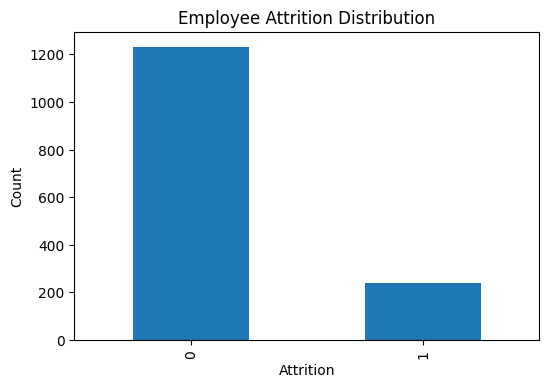

Attrition
0    1233
1     237
Name: count, dtype: int64


In [11]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6,4))
attrition_counts.plot(kind="bar")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

print(attrition_counts)

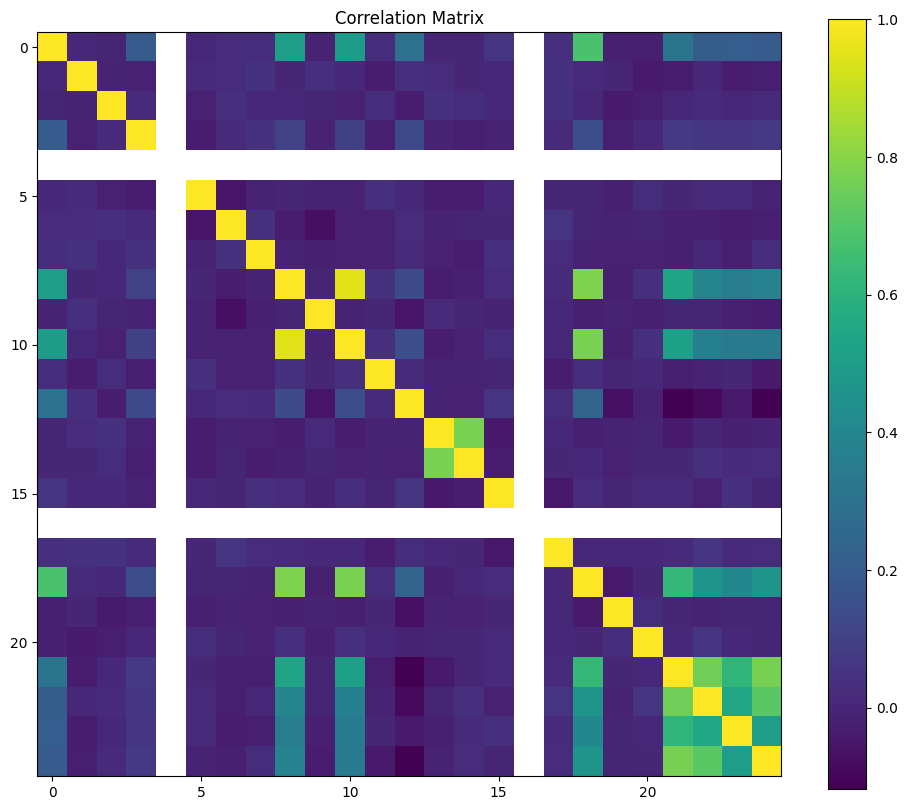

In [12]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

Training Decision Tree...
Training Random Forest...
Training XGBoost...

=== MODEL PERFORMANCE COMPARISON ===
        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree    0.7857     0.3261  0.3191    0.3226   0.5968
Random Forest    0.8401     0.5000  0.2128    0.2985   0.7805
      XGBoost    0.8776     0.7200  0.3830    0.5000   0.8041


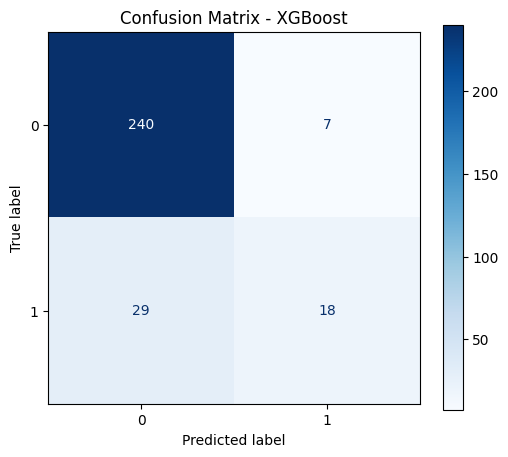

Best Model: XGBoost with ROC-AUC: 0.8041


['/content/drive/MyDrive/xai_sme_framework/xgb_model.pkl']

In [14]:


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Store results
results = []
best_model = None
best_auc = 0

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_model_name = name

# Display Results Table
results_df = pd.DataFrame(results)
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))

# Save results to CSV for your dissertation table
results_df.to_csv(f'{PROJECT_PATH}/model_performance.csv', index=False)

# Plot Confusion Matrix for the Best Model (XGBoost)
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
y_pred_best = best_model.predict(X_test_processed)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig(f'{PROJECT_PATH}/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best Model: {best_model_name} with ROC-AUC: {best_auc:.4f}")

# Save the best model
joblib.dump(best_model, f'{PROJECT_PATH}/xgb_model.pkl')

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        estimator=model,
        X=X_train_res,
        y=y_train_res,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std Dev": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

# Fix: Create the 'metrics' directory if it doesn't exist
os.makedirs(f"{PROJECT_PATH}/metrics", exist_ok=True)

cv_results_df.to_csv(
    f"{PROJECT_PATH}/metrics/cross_validation_results.csv",
    index=False
)

,Model,Mean F1,Std Dev
0,Decision Tree,0.854857,0.017351
1,Random Forest,0.932268,0.011172
2,XGBoost,0.926969,0.007305


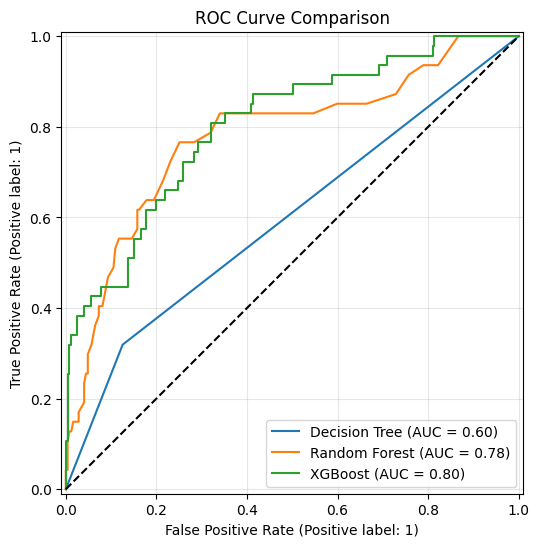

In [22]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test_processed,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")

plt.grid(alpha=0.3)

plt.savefig(
    f"{PROJECT_PATH}/figures/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

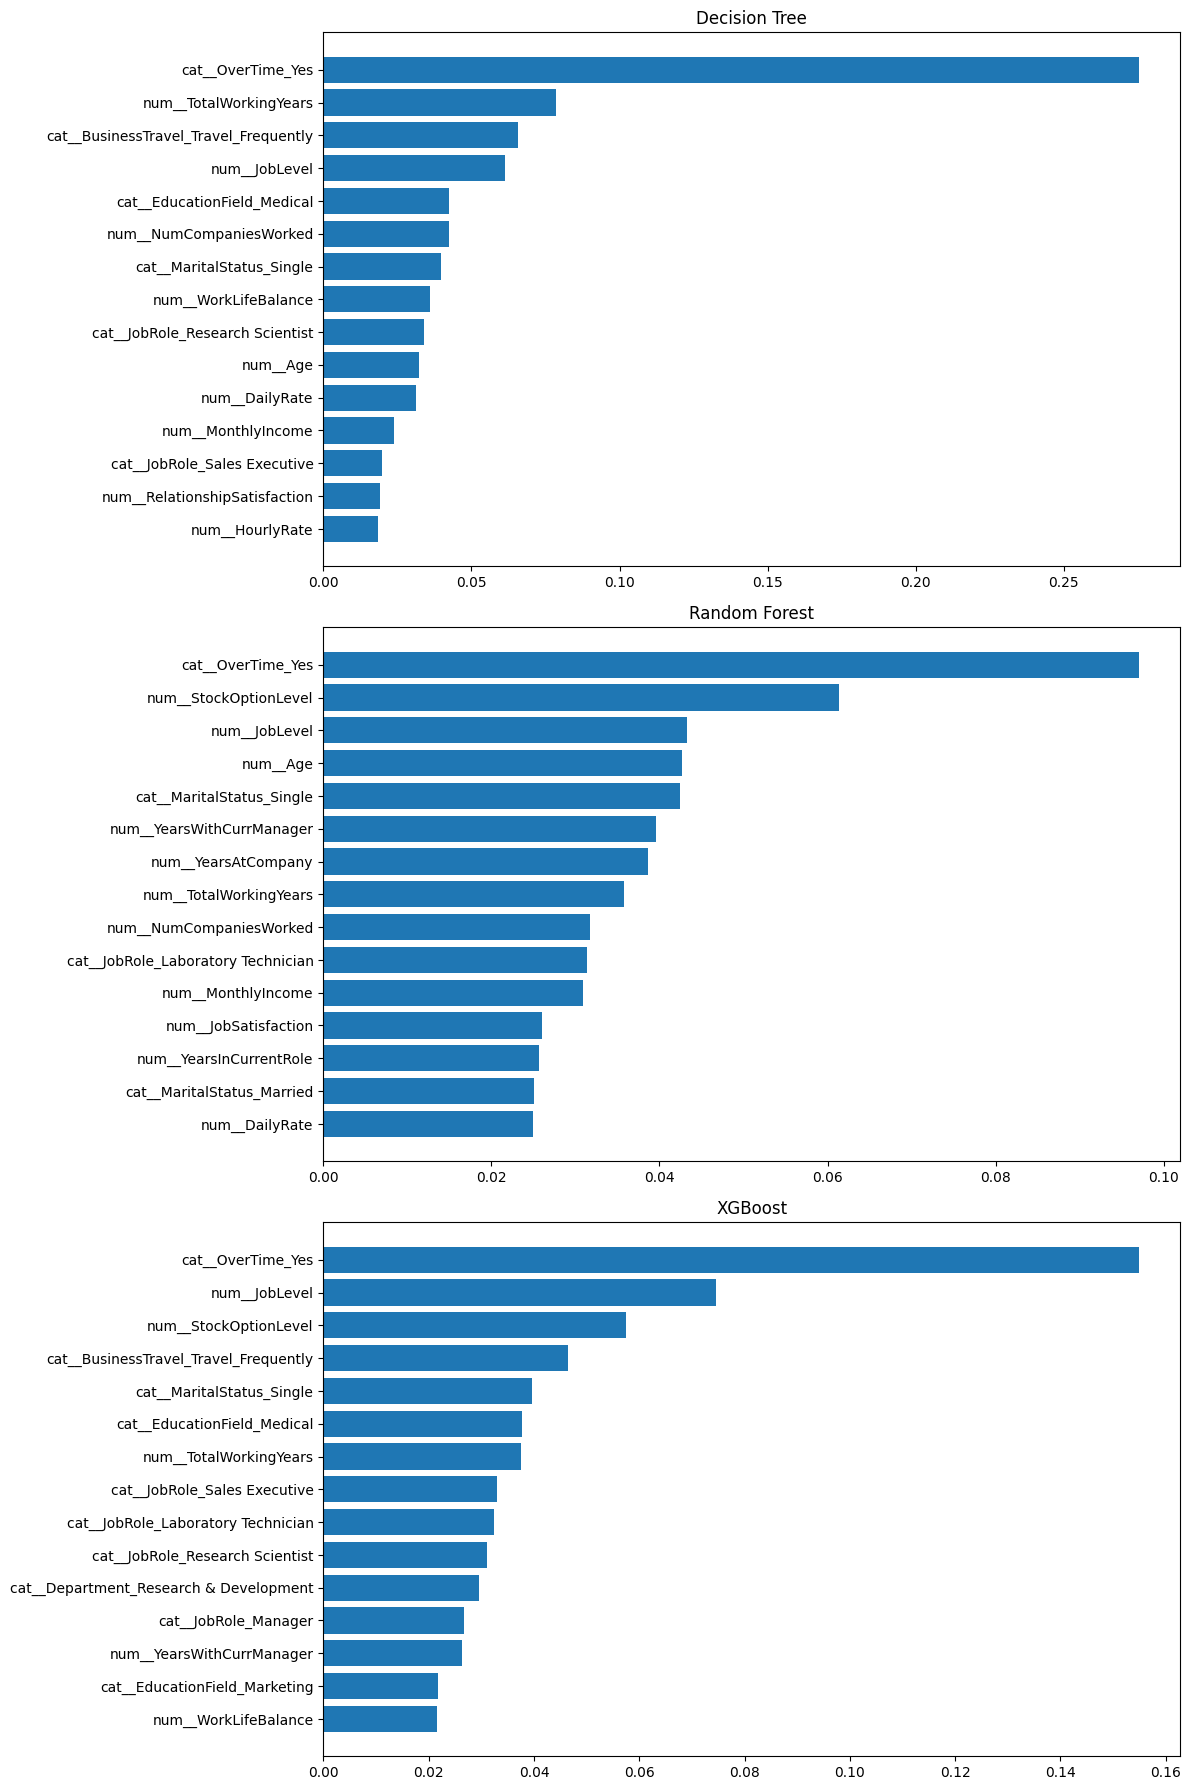

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12,18))

for idx, (name, model) in enumerate(models.items()):

    importance = pd.DataFrame({

        "Feature": feature_names,

        "Importance": model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    axes[idx].barh(
        importance["Feature"],
        importance["Importance"]
    )

    axes[idx].invert_yaxis()

    axes[idx].set_title(name)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_PATH}/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives : {tp}")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Build results dataframe
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred
error_analysis["Probability"] = y_proba

# Prediction outcome
error_analysis["Outcome"] = np.select(
    [
        (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 1),
        (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 0),
        (error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1),
        (error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0),
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
    ],
    default="Unknown"
)

display(error_analysis.head())

# Save for later use
os.makedirs(f"{PROJECT_PATH}/reports", exist_ok=True)
error_analysis.to_csv(
    f"{PROJECT_PATH}/reports/error_analysis.csv",
    index=False
)

print("Error analysis report saved.")

True Positives : 18
True Negatives : 240
False Positives: 7
False Negatives: 29


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Actual,Predicted,Probability,Outcome
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,1,4,Female,...,2,3,1,0,0,0,0,0,0.385924,True Negative
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,1,Female,...,5,3,10,5,7,7,0,0,0.004921,True Negative
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,1,3,Male,...,3,2,5,4,0,1,0,0,0.020873,True Negative
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,1,3,Male,...,4,2,25,9,14,13,0,0,0.002292,True Negative
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,1,4,Male,...,0,2,1,0,0,0,1,0,0.092084,False Negative


Error analysis report saved.


In [30]:
summary = (
    error_analysis["Outcome"]
    .value_counts()
    .rename_axis("Prediction Outcome")
    .reset_index(name="Count")
)

display(summary)

,Prediction Outcome,Count
0,True Negative,240
1,False Negative,29
2,True Positive,18
3,False Positive,7


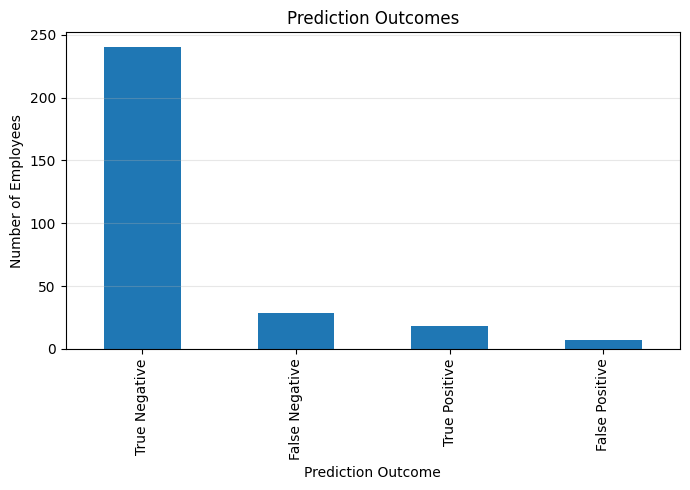

In [31]:
plt.figure(figsize=(7,5))

summary.set_index("Prediction Outcome")["Count"].plot(kind="bar")

plt.title("Prediction Outcomes")

plt.ylabel("Number of Employees")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_PATH}/figures/error_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
misclassified = error_analysis[
    error_analysis["Outcome"].isin([
        "False Positive",
        "False Negative"
    ])
]

misclassified = misclassified.sort_values(
    by="Probability",
    ascending=False
)

print(f"Total Misclassified Employees: {len(misclassified)}")

display(misclassified.head(10))

misclassified.to_csv(
    f"{PROJECT_PATH}/reports/misclassified_employees.csv",
    index=False
)

Total Misclassified Employees: 36


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Actual,Predicted,Probability,Outcome
301,18,Travel_Rarely,812,Sales,10,3,Medical,1,4,Female,...,2,3,0,0,0,0,0,1,0.875892,False Positive
310,31,Travel_Rarely,106,Human Resources,2,3,Human Resources,1,1,Male,...,1,3,2,2,1,0,0,1,0.631776,False Positive
686,41,Travel_Rarely,263,Research & Development,6,3,Medical,1,4,Male,...,3,3,18,13,2,17,0,1,0.562719,False Positive
292,31,Travel_Frequently,444,Sales,5,3,Marketing,1,4,Female,...,5,2,2,2,2,2,0,1,0.545316,False Positive
1402,31,Travel_Rarely,1276,Research & Development,2,1,Medical,1,4,Female,...,4,3,1,0,0,0,0,1,0.542346,False Positive
1241,32,Travel_Rarely,371,Sales,19,3,Life Sciences,1,4,Male,...,2,1,4,3,0,2,0,1,0.533473,False Positive
17,22,Non-Travel,1123,Research & Development,16,2,Medical,1,4,Male,...,2,2,1,0,0,0,0,1,0.500926,False Positive
709,31,Non-Travel,335,Research & Development,9,2,Medical,1,3,Male,...,0,3,3,2,1,2,1,0,0.453901,False Negative
1236,36,Travel_Rarely,1456,Sales,13,5,Marketing,1,2,Male,...,3,3,2,2,2,2,1,0,0.377802,False Negative
645,29,Travel_Rarely,341,Sales,1,3,Medical,1,2,Female,...,3,3,3,2,0,2,1,0,0.320833,False Negative


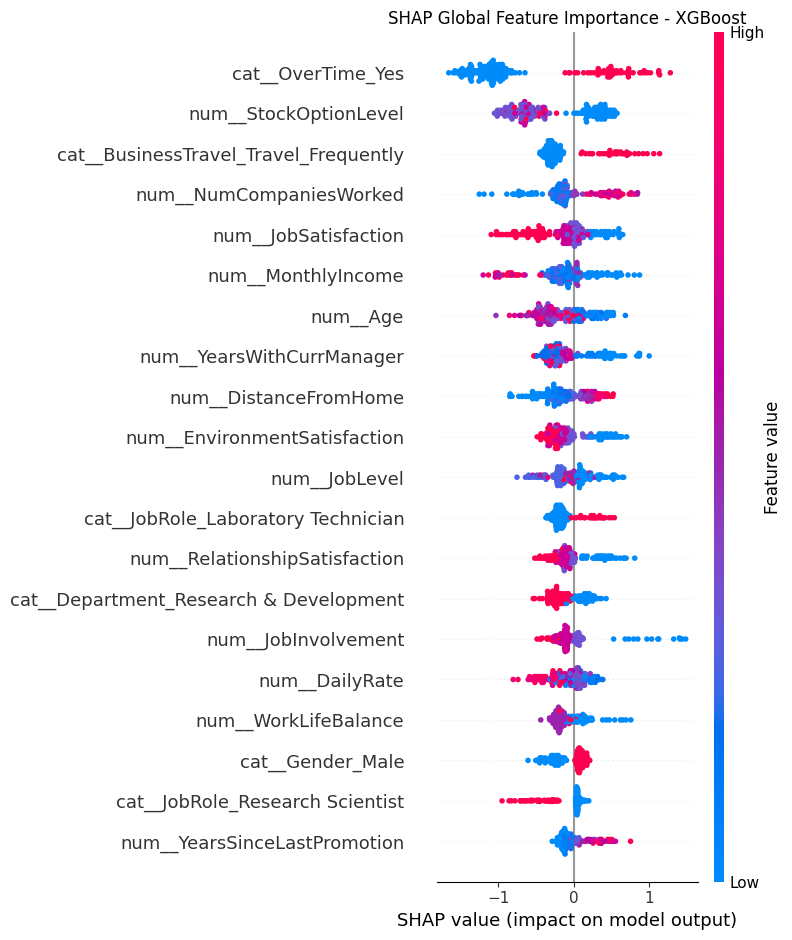

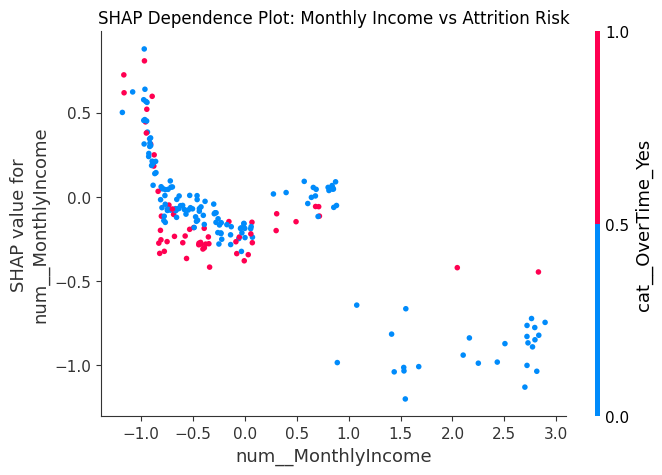

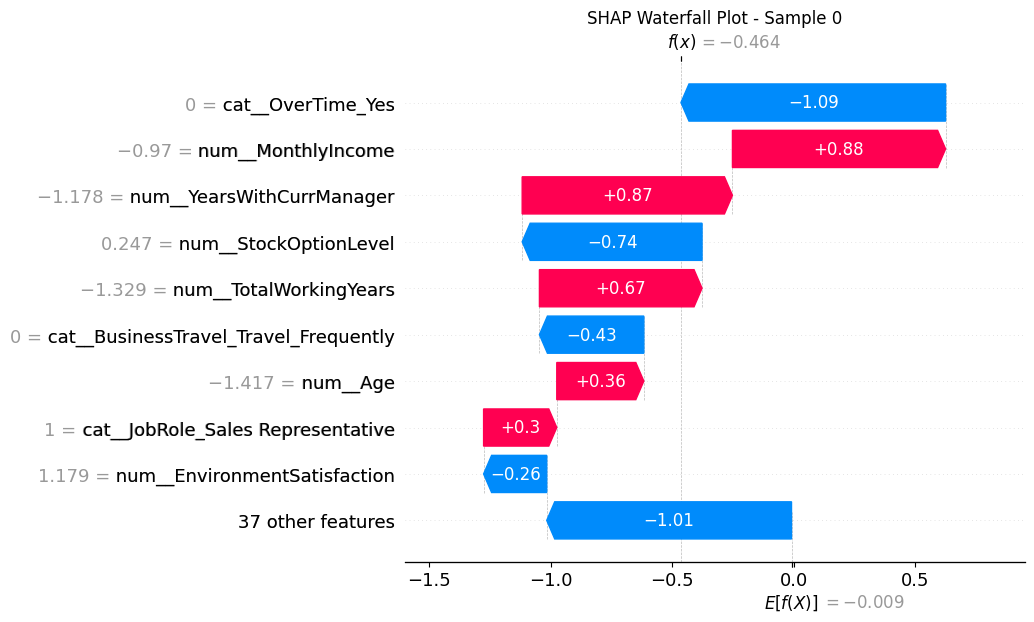

SHAP analysis complete. Figures saved to Drive.


In [16]:
import shap
import pickle
import matplotlib.pyplot as plt

# Fix: Remove data=background to use tree_path_dependent perturbation and avoid NotImplementedError
explainer = shap.TreeExplainer(best_model)

X_test_sample = X_test_processed[:200]
shap_values = explainer.shap_values(X_test_sample)

# Save explainer
with open(f'{PROJECT_PATH}/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Global Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Global Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/figures/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Dependence Plot
shap.dependence_plot("num__MonthlyIncome", shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Dependence Plot: Monthly Income vs Attrition Risk")
plt.savefig(f'{PROJECT_PATH}/figures/shap_dependence_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Local Explanation (Waterfall) for a sample
sample_idx = 0
# For XGBoost, shap_values is often a simple array if binary classification
# Waterfall plot expects a single Explanation object
exp = shap.Explanation(values=shap_values[sample_idx],
                       base_values=explainer.expected_value,
                       data=X_test_sample[sample_idx],
                       feature_names=feature_names)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp, show=False)
plt.title(f"SHAP Waterfall Plot - Sample {sample_idx}")
plt.savefig(f'{PROJECT_PATH}/figures/shap_waterfall_sample.png', dpi=300, bbox_inches='tight')
plt.show()

print("SHAP analysis complete. Figures saved to Drive.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=465eff7be935e398dc58e2c2b4e7ef858fb608bc9554ebd65e24ce4af8415e57
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

--- LIME Explanation for Employee Sample 1 (Predicted: Stay) ---
Top contributing factors:
  - cat__OverTime_Yes <= 0.00: -0.127
  - cat__BusinessTravel_Travel_Frequently <= 0.00: -0.067
  - cat__Gender_Male <= 0.00: -0.034
  - 0.00 < cat__Department_Research & Development <= 1.00: 0.033
  - cat__JobRole_Laboratory Technician <= 0.00: -0.027


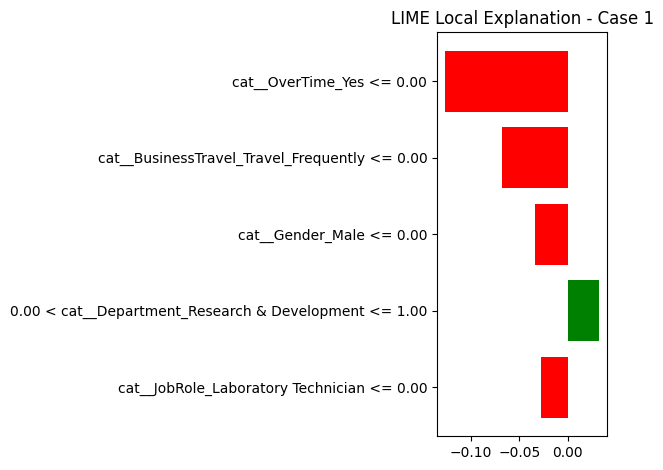


--- LIME Explanation for Employee Sample 2 (Predicted: Stay) ---
Top contributing factors:
  - 0.00 < cat__OverTime_Yes <= 1.00: 0.120
  - cat__BusinessTravel_Travel_Frequently <= 0.00: -0.067
  - num__MonthlyIncome > 0.10: -0.055
  - num__StockOptionLevel <= -0.94: 0.030
  - cat__JobRole_Laboratory Technician <= 0.00: -0.029


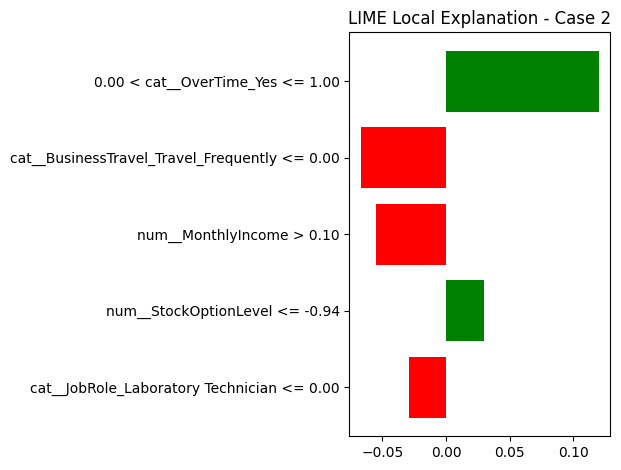


--- LIME Explanation for Employee Sample 3 (Predicted: Stay) ---
Top contributing factors:
  - cat__OverTime_Yes <= 0.00: -0.124
  - cat__BusinessTravel_Travel_Frequently <= 0.00: -0.067
  - num__StockOptionLevel <= -0.94: 0.031
  - cat__Gender_Male <= 0.00: -0.030
  - cat__JobRole_Laboratory Technician <= 0.00: -0.030


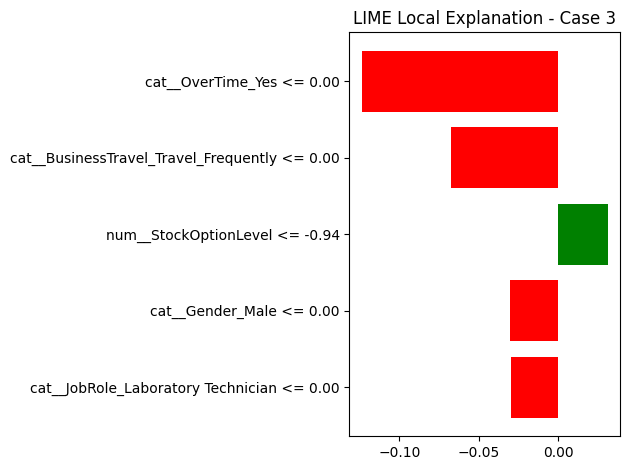

In [19]:
!pip install lime

import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,  # SMOTE resampled data
    feature_names=feature_names,
    class_names=['No Attrition', 'Attrition'],
    mode='classification',
    verbose=False
)

for i, idx in enumerate([1, 5, 10]):  # just picking arbitrary indices
    instance = X_test_processed[idx]
    pred_proba = best_model.predict_proba(instance.reshape(1, -1))
    pred_class = np.argmax(pred_proba)

    print(f"\n--- LIME Explanation for Employee Sample {i+1} (Predicted: {'Attrition' if pred_class==1 else 'Stay'}) ---")

    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=best_model.predict_proba,
        num_features=5
    )

    # Show the explanation as a list of (feature, weight)
    print("Top contributing factors:")
    for feature, weight in exp.as_list():
        print(f"  - {feature}: {weight:.3f}")

    # Save the LIME plot
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Local Explanation - Case {i+1}")
    plt.tight_layout()
    plt.savefig(f'{PROJECT_PATH}/figures/lime_case_{i+1}.png', dpi=300, bbox_inches='tight')
    plt.show()

### **XAI Audit & Interpretability Report**
This section consolidates the findings from SHAP (Global) and LIME (Local) to ensure the model's logic is sound for the dissertation.

In [34]:
import pandas as pd

# 1. Summarize Global SHAP Importance
shap_importance = np.abs(shap_values).mean(0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Global_SHAP_Impact': shap_importance
}).sort_values(by='Global_SHAP_Impact', ascending=False)

print("--- Top 10 Global Drivers of Attrition (SHAP) ---")
display(importance_df.head(10))

fn_cases = misclassified[misclassified['Outcome'] == 'False Negative'].index

if len(fn_cases) > 0:
    target_idx = 0 # First False Negative
    instance_loc = X_test.index.get_loc(fn_cases[target_idx])

    print(f"\n--- Auditing False Negative Case (Index {fn_cases[target_idx]}) ---")
    exp = lime_explainer.explain_instance(
        data_row=X_test_processed[instance_loc],
        predict_fn=best_model.predict_proba,
        num_features=5
    )
    for feature, weight in exp.as_list():
        print(f"  - {feature}: {weight:.3f}")
else:
    print("No False Negatives found in the current test slice.")

--- Top 10 Global Drivers of Attrition (SHAP) ---


,Feature,Global_SHAP_Impact
45,cat__OverTime_Yes,0.986886
17,num__StockOptionLevel,0.511983
25,cat__BusinessTravel_Travel_Frequently,0.336446
12,num__NumCompaniesWorked,0.314715
9,num__JobSatisfaction,0.295621
10,num__MonthlyIncome,0.292428
0,num__Age,0.288372
24,num__YearsWithCurrManager,0.284906
2,num__DistanceFromHome,0.263814
5,num__EnvironmentSatisfaction,0.244214



--- Auditing False Negative Case (Index 709) ---
  - 0.00 < cat__OverTime_Yes <= 1.00: 0.120
  - cat__BusinessTravel_Travel_Frequently <= 0.00: -0.066
  - num__StockOptionLevel <= -0.94: 0.029
  - cat__JobRole_Laboratory Technician <= 0.00: -0.027
  - 0.00 < cat__Gender_Male <= 1.00: 0.024


In [35]:
import shutil

shutil.make_archive('/content/xai_framework_export', 'zip', PROJECT_PATH)

print("="*50)
for root, dirs, files in os.walk(PROJECT_PATH):
    for file in files:
        print(f"   - {os.path.join(root, file)}")


📁 GENERATED FILES FOR YOUR DISSERTATION:
   - /content/drive/MyDrive/xai_sme_framework/preprocessor.pkl
   - /content/drive/MyDrive/xai_sme_framework/feature_names.pkl
   - /content/drive/MyDrive/xai_sme_framework/model_performance.csv
   - /content/drive/MyDrive/xai_sme_framework/xgb_model.pkl
   - /content/drive/MyDrive/xai_sme_framework/shap_explainer.pkl
   - /content/drive/MyDrive/xai_sme_framework/figures/confusion_matrix.png
   - /content/drive/MyDrive/xai_sme_framework/figures/shap_summary_plot.png
   - /content/drive/MyDrive/xai_sme_framework/figures/shap_dependence_plot.png
   - /content/drive/MyDrive/xai_sme_framework/figures/shap_waterfall_sample.png
   - /content/drive/MyDrive/xai_sme_framework/figures/lime_case_1.png
   - /content/drive/MyDrive/xai_sme_framework/figures/lime_case_2.png
   - /content/drive/MyDrive/xai_sme_framework/figures/lime_case_3.png
   - /content/drive/MyDrive/xai_sme_framework/figures/roc_curve_comparison.png
   - /content/drive/MyDrive/xai_sme_fra

In [36]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximizes F1 score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal Decision Threshold: {best_threshold:.4f}")

# Apply optimal threshold
y_pred_opt = (y_proba >= best_threshold).astype(int)

print("\n--- Optimized Model Metrics ---")
print(classification_report(y_test, y_pred_opt))

Optimal Decision Threshold: 0.5255

--- Optimized Model Metrics ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.75      0.38      0.51        47

    accuracy                           0.88       294
   macro avg       0.82      0.68      0.72       294
weighted avg       0.87      0.88      0.86       294



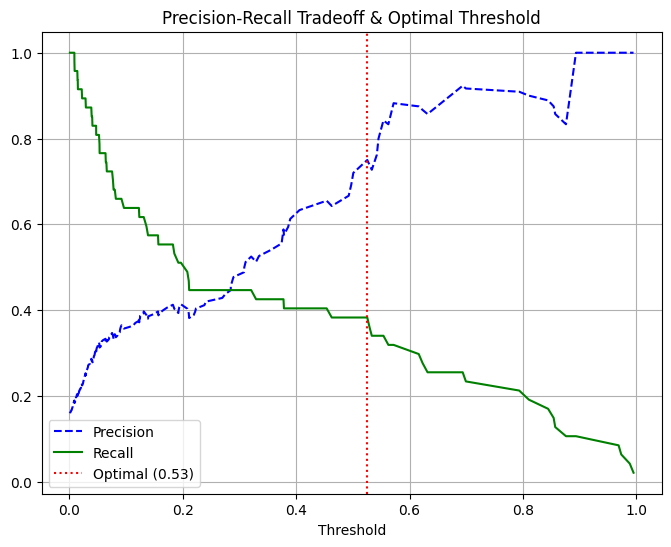

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Optimal ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.title('Precision-Recall Tradeoff & Optimal Threshold')
plt.legend()
plt.grid(True)
plt.savefig(f'{PROJECT_PATH}/figures/threshold_optimization.png')
plt.show()

In [41]:
comparison_idx = 0
instance_to_audit = X_test_processed[comparison_idx]

# Get LIME weights
lime_exp = lime_explainer.explain_instance(instance_to_audit, best_model.predict_proba, num_features=len(feature_names))
lime_dict = dict(lime_exp.as_list())

# Get SHAP weights
shap_dict = dict(zip(feature_names, shap_values[comparison_idx]))

# Prepare Comparison Table
audit_data = []
for feat in feature_names:
    # Find LIME key that contains the feature name substring
    lime_val = next((v for k, v in lime_dict.items() if feat in k), 0)
    audit_data.append({
        'Feature': feat,
        'SHAP_Value': shap_dict[feat],
        'LIME_Weight': lime_val
    })

audit_df = pd.DataFrame(audit_data).sort_values(by='SHAP_Value', key=abs, ascending=False).head(10)

print(f"--- Explanation Consistency Audit (Sample {comparison_idx}) ---")
display(audit_df)


--- Explanation Consistency Audit (Sample 0) ---


,Feature,SHAP_Value,LIME_Weight
45,cat__OverTime_Yes,-1.089540,-0.124979
10,num__MonthlyIncome,0.877666,0.023501
24,num__YearsWithCurrManager,0.865746,0.001942
17,num__StockOptionLevel,-0.740575,0.026898
18,num__TotalWorkingYears,0.669595,-0.001336
25,cat__BusinessTravel_Travel_Frequently,-0.429904,-0.071273
0,num__Age,0.358443,0.014296
42,cat__JobRole_Sales Representative,0.301301,0.001626
5,num__EnvironmentSatisfaction,-0.259921,-0.000508
6,num__HourlyRate,-0.257711,-0.004857


In [40]:
comparison_idx = 0 # Auditing the first sample in our test set
instance_to_audit = X_test_processed[comparison_idx]

# Get LIME weights
lime_exp = lime_explainer.explain_instance(instance_to_audit, best_model.predict_proba, num_features=len(feature_names))
lime_dict = dict(lime_exp.as_list())

# Get SHAP weights
shap_dict = dict(zip(feature_names, shap_values[comparison_idx]))

# Prepare Comparison Table
audit_data = []
for feat in feature_names:
    # LIME features are often strings like 'feat > value', so we do a substring match
    lime_val = next((v for k, v in lime_dict.items() if feat in k), 0)
    audit_data.append({
        'Feature': feat,
        'SHAP_Value': shap_dict[feat],
        'LIME_Weight': lime_val
    })

audit_df = pd.DataFrame(audit_data).sort_values(by='SHAP_Value', key=abs, ascending=False).head(10)

print(f"--- Explanation Consistency Audit (Sample {comparison_idx}) ---")
display(audit_df)

--- Explanation Consistency Audit (Sample 0) ---


,Feature,SHAP_Value,LIME_Weight
45,cat__OverTime_Yes,-1.089540,-0.120925
10,num__MonthlyIncome,0.877666,0.023770
24,num__YearsWithCurrManager,0.865746,-0.000916
17,num__StockOptionLevel,-0.740575,0.019812
18,num__TotalWorkingYears,0.669595,0.003311
25,cat__BusinessTravel_Travel_Frequently,-0.429904,-0.064381
0,num__Age,0.358443,0.018047
42,cat__JobRole_Sales Representative,0.301301,0.007039
5,num__EnvironmentSatisfaction,-0.259921,-0.003591
6,num__HourlyRate,-0.257711,-0.010012
